<a href="https://colab.research.google.com/github/Nyanta432/Dinh_vi_cuon_vi_sai/blob/main/Forwardmodel_don.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TÓM TẮT QUY TRÌNH CHUYỂN ĐỔI VÀ TỐI ƯU HÓA THUẬT TOÁN ĐỊNH VỊ TỪ TRƯỜNG 6D (MATLAB -> PYTHON)

Toàn bộ mã nguồn định vị từ trường đã được chuyển đổi thành công từ MATLAB sang Python (Google Colab). Hệ thống được tái cấu trúc thành một luồng thực thi tự động, xuyên suốt (End-to-End), bao gồm 5 phân đoạn cốt lõi:

## Section 1: Cấu hình Hệ thống & Khởi tạo Dữ liệu (System Config)
* **Mục đích:** Số hóa các tham số phần cứng của hệ thống bao gồm: số vòng dây TX/RX ($N_{tx} = 300, N_{rx} = 100$), dòng điện kích thích ($1\text{ A}$), bán kính cuộn dây ($0.06\text{ m}$), và mảng tiết diện thu từ tính ($AK$).
* **Xử lý:** Tải dữ liệu quỹ đạo thực tế (Ground Truth) và tín hiệu cảm ứng điện từ (EMF Measured) từ file `.csv`, đồng thời quy đổi đồng nhất các đơn vị đo lường (mm sang m).

## Section 2: Lõi Toán học Vật lý (Forward Model - Dipole Approximation)
* **Mục đích:** Xây dựng phương trình tính toán tín hiệu EMF lý thuyết.
* **Kỹ thuật cốt lõi:** Thay vì sử dụng mô hình vi sai bậc 4 ($1/r^4$), hệ thống áp dụng **Mô hình Cuộn Đơn (Single Point Dipole - $1/r^3$)**. Việc xấp xỉ này đóng vai trò như một "đường bao" (envelope) giúp thuật toán không bị sụp đổ (singularity) tại các điểm tiệm cận cuộn phát (Near-field), đồng thời vẫn giữ được đặc tính suy hao của từ trường.

## Section 3: Vòng lặp Hiệu chuẩn Tự động (Auto-Calibration Loop)
* **Mục đích:** Tìm kiếm tọa độ thực tế của 3 cuộn phát (TX) và hệ số bù trừ tín hiệu (K).
* **Cải tiến tự động hóa:** Tích hợp quy trình hiệu chuẩn của cả 3 cuộn TX vào một vòng lặp tự động (loại bỏ hoàn toàn thao tác copy-paste biến số thủ công từ code `maincalib` sang `inverse`).
* **Kỹ thuật Tối ưu:** Sử dụng hàm `scipy.optimize.least_squares` với thuật toán **Trust Region Reflective (trf)**.
* **Xử lý tỷ lệ ma trận (Crucial Fix):** Kích hoạt cơ chế `x_scale='jac'` nhằm buộc Python mô phỏng lại cách tự động cân bằng ma trận Jacobian của hàm `lsqnonlin` (MATLAB). Điều này giúp thuật toán xử lý triệt để sự chênh lệch tỷ lệ cực lớn giữa các biến số (Tọa độ $\sim 0.5$, Góc $\sim 180$, Hệ số K $\sim 0.001$), đảm bảo hàm mục tiêu hội tụ chính xác và bám sát đỉnh tín hiệu đo đạc.

## Section 4: Giải mã Tọa độ 6D (Inverse Kinematics)
* **Mục đích:** Dò tìm quỹ đạo di chuyển thực tế của viên nang 6-DOF (x, y, z, roll, pitch, yaw).
* **Xử lý:** Kế thừa bộ thông số (Tọa độ TX và Hệ số K) đã được tinh chỉnh từ Section 3 để chạy bài toán ngược. Thuật toán thiết lập hộp giới hạn (Bounds) bám sát quỹ đạo nhằm ngăn chặn các cực tiểu cục bộ (local minima), qua đó tính toán thời gian suy luận (Inference Time) và tốc độ FPS thực tế của bộ giải.

## Section 5: Đánh giá Lỗi & Trực quan hóa (Error Metrics & Visualization)
* **Mục đích:** Đánh giá độ tin cậy của mô hình sau hiệu chuẩn.
* **Kết xuất:**
  1. Tính toán sai số vị trí trung bình bình phương (RMSE).
  2. Vẽ đồ thị 3D so sánh quỹ đạo Ground Truth và quỹ đạo phân tích (Estimated Path).
  3. Xuất ma trận đồ thị 3x3 so sánh tín hiệu EMF lý thuyết (Post-Calib) và tín hiệu đo thực tế nhằm minh chứng độ bám sát của thuật toán trên toàn bộ dải tín hiệu.

# Section 1: Cấu hình vật lý và nạp dữ liệu

In [ ]:
# ==============================================================================
# SECTION 1: CẤU HÌNH THÔNG SỐ VẬT LÝ VÀ NẠP DỮ LIỆU
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import time
import os
import copy

class SystemConfig:
    """
    Lớp lưu trữ toàn bộ các thông số vật lý của phần cứng hệ thống định vị.
    Đóng vai trò như hằng số toàn cục (Global Constants) trong suốt quá trình chạy.
    """
    def __init__(self):
        # 1. THÔNG SỐ CUỘN PHÁT (TX - Transmitter)
        self.Ntx = 300              # Số vòng dây của mỗi cuộn phát
        self.R = 0.06               # Bán kính cuộn phát (m) -> Tính tiết diện Atx = pi * R^2
        self.I = np.array([1.0, 1.0, 1.0])  # Dòng điện kích thích cấp cho 3 cuộn TX (Ampe)
        self.f = np.array([5053, 6911, 5932]) # Tần số hoạt động riêng biệt của 3 cuộn (Hz)

        # 2. THÔNG SỐ CUỘN THU (RX - Receiver / Capsule)
        self.Nrx = 100              # Số vòng dây của cuộn thu (mỗi nửa của cuộn vi sai)
        self.d_diff = 0.25e-3       # Khoảng cách vi sai giữa 2 nửa cuộn dây (0.25 mm)
        # Tiết diện hiệu dụng của 3 trục thu tín hiệu (X, Z, Y) nhân với 10^-6 để đổi ra m^2
        self.AK = np.array([np.pi * 2**2, 6.79 * 4.00, 6.00 * 6.87]) * 1e-6

        # Hằng số từ thẩm của chân không
        self.mu0 = 4 * np.pi * 1e-7

        # 3. TỌA ĐỘ MỒI BAN ĐẦU (Initial TX Positions)
        # Cấu trúc ma trận 6x3: [x, y, z, roll, pitch, yaw]^T cho 3 cuộn TX
        # Tọa độ này được đo đạc thô bằng thước/cơ khí (Trục Y hướng dương)
        self.TX_positions = np.array([
            [0.35146, 0.61931, 0.19348, 15,   0,   0],  # TX1
            [0.42173, 0.51066, 0.19350,  0, -15, -30],  # TX2
            [0.29150, 0.51068, 0.19350,  0,  15,  30]   # TX3
        ]).T

sys_pre = SystemConfig()

# TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU TỪ CSV
filename = 'conenorot_2_data.csv'
if not os.path.exists(filename):
    raise FileNotFoundError(f"⚠️ Không tìm thấy file '{filename}'. Vui lòng upload lên Colab.")

data = pd.read_csv(filename, header=None).values
N_samples = data.shape[0]

# Trích xuất 9 cột đầu tiên: Tín hiệu EMF thu được (Measured)
emf_meas = data[:, 0:9]

# Trích xuất 6 cột tiếp theo: Quỹ đạo thực tế (Ground Truth Pose)
gt_pose = np.zeros((N_samples, 6))
gt_pose[:, 0:3] = data[:, 9:12] / 1000.0  # Chuyển đổi tọa độ (x,y,z) từ mm sang mét
gt_pose[:, 3:6] = data[:, 12:15]          # Giữ nguyên góc quay (roll, pitch, yaw) theo độ

print(f"✅ Đã nạp {N_samples} mẫu. Sẵn sàng cho Auto-Calibration.")

✅ Đã nạp 319 mẫu. Sẵn sàng cho Auto-Calibration.


# Section 2: Forward Model (cuộn đơn)

In [ ]:
# ==============================================================================
# SECTION 2: LÕI TOÁN HỌC VẬT LÝ (FORWARD MODEL - SINGLE DIPOLE)
# ==============================================================================

# CÁC HÀM TẠO MA TRẬN XOAY (Rotation Matrices)
# Quy ước xoay Euler: Z-Y-X (Roll quanh X, Pitch quanh Y, Yaw quanh Z)
def rotx(a):
    a = np.radians(a)
    return np.array([[1, 0, 0], [0, np.cos(a), -np.sin(a)], [0, np.sin(a), np.cos(a)]])

def roty(a):
    a = np.radians(a)
    return np.array([[np.cos(a), 0, np.sin(a)], [0, 1, 0], [-np.sin(a), 0, np.cos(a)]])

def rotz(a):
    a = np.radians(a)
    return np.array([[np.cos(a), -np.sin(a), 0], [np.sin(a), np.cos(a), 0], [0, 0, 1]])

def forwardModel_dio(params, sys, rx_idx):
    """
    Hàm tính toán điện áp cảm ứng (EMF) lý thuyết dựa trên Mô hình Cuộn Đơn (Dipole Model).
    - params: Vector 6-DOF của viên nang [x, y, z, roll, pitch, yaw]
    - sys: Đối tượng chứa cấu hình hệ thống
    - rx_idx: Chỉ số trục của cuộn thu (0, 1, 2 tương ứng X, Z, Y)
    - Trả về: Vector 3 phần tử (Tín hiệu EMF từ 3 cuộn TX tác động lên trục RX đang xét)
    """
    x_rx, y_rx, z_rx = params[0:3]
    roll, pitch, yaw = params[3:6]

    # 1. Xác định Vector định hướng của trục thu (RX Vector)
    RCE = rotz(yaw) @ roty(pitch) @ rotx(roll)
    if rx_idx == 0:     # Trục 1 dọc theo X
        RXk = RCE @ np.array([1, 0, 0])
    elif rx_idx == 1:   # Trục 2 dọc theo Z
        RXk = RCE @ np.array([0, 0, 1])
    elif rx_idx == 2:   # Trục 3 dọc theo Y
        RXk = RCE @ np.array([0, 1, 0])

    Atx = np.pi * sys.R**2 # Diện tích cuộn phát
    emf_out = np.zeros(3)

    # 2. Vòng lặp tính toán từ trường từ 3 cuộn TX
    for i in range(3):
        x_tx, y_tx, z_tx = sys.TX_positions[0:3, i]
        roll_tx, pitch_tx, yaw_tx = sys.TX_positions[3:6, i]

        # Vector khoảng cách từ tâm TX đến tâm RX
        r_vec = np.array([x_rx - x_tx, y_rx - y_tx, z_rx - z_tx])
        r = np.linalg.norm(r_vec)             # Độ dài (m)
        r_hat = r_vec / (r + 1e-15)           # Vector đơn vị (chống chia cho 0)

        # Tính Momen từ m (Dipole Moment) của cuộn phát
        m_local = sys.Ntx * sys.I[i]
        Rtx = rotz(yaw_tx) @ roty(pitch_tx) @ rotx(roll_tx)
        D = Rtx @ np.array([0, 0, 1])         # Hướng của từ trường TX (Trục Z cục bộ)
        m_vec = m_local * Atx * D

        # Phương trình Từ trường Dipole: B = (mu0 / 4.pi.r^3) * [3(m . r_hat)r_hat - m]
        B = (sys.mu0 / (4 * np.pi * r**3)) * (3 * np.dot(m_vec, r_hat) * r_hat - m_vec)

        # Công thức Faraday: EMF = 2.pi.f * |B dot RXk| (Bỏ qua N_rx và Area ở đây vì sẽ được Calib sau)
        emf_out[i] = 2 * np.pi * sys.f[i] * np.abs(np.dot(B, RXk))

    return emf_out

# Section 3: Hiệu chuẩn từng cuộn TX

In [ ]:
# ==============================================================================
# SECTION 3: AUTO-CALIBRATION LOOP (TÌM TỌA ĐỘ TX VÀ HỆ SỐ KHUẾCH ĐẠI K)
# ==============================================================================
def calib_cost_func(x_opt, gt_pose_data, emf_meas_data, sys, tx_idx, nRx, k_base):
    """
    Hàm Mục Tiêu (Cost Function) cho thuật toán Least Squares.
    - x_opt: Vector biến trạng thái cần tối ưu [x, y, z, roll, pitch, yaw, K_mul_1, K_mul_2, K_mul_3]
    - K_mul: Hệ số nhân (Multiplier) để tránh "Bẫy Gradient" khi số quá nhỏ.
    """
    tx_param = x_opt[0:6]

    # GIẢI MÃ K: K_thực_tế = K_Multiplier * K_mồi_ban_đầu
    # Kỹ thuật Normalization này giúp thuật toán tối ưu các số xoay quanh 1.0 thay vì 0.001
    K = x_opt[6 : 6+nRx] * k_base

    # Tạo bản sao hệ thống để thử nghiệm tọa độ mới mà không làm hỏng dữ liệu gốc
    sys_local = copy.deepcopy(sys)
    sys_local.TX_positions[:, tx_idx] = tx_param

    N = gt_pose_data.shape[0]
    F = np.zeros(N * nRx)

    for j in range(nRx):
        for i in range(N):
            # Tính EMF lý thuyết và nhân với hệ số K (Scale Factor)
            emf_model_all = forwardModel_dio(gt_pose_data[i, :], sys_local, j)
            emf_model = K[j] * emf_model_all[tx_idx]

            # Lấy EMF thực tế đo được
            emf_meas_val = emf_meas_data[i, tx_idx + 3 * j]

            # Lỗi tuyệt đối (Absolute Error): F = Lý thuyết - Thực tế
            F[j * N + i] = (emf_model - emf_meas_val)
    return F

# Tạo biến lưu trữ cấu hình hệ thống SAU KHI ĐÃ CALIB (Post-Calib)
sys_post = copy.deepcopy(sys_pre)
K_post = np.zeros((3, 3))

# Hệ số K mồi ban đầu (Nrx * Area) dùng làm Hằng số gốc (Base)
k_base = np.array([sys_pre.Nrx * sys_pre.AK[i] for i in range(3)])

print("🚀 BẮT ĐẦU HIỆU CHUẨN TỰ ĐỘNG CHO 3 CUỘN TX...")
for tx_idx in range(3):
    print(f"\nĐang chạy thuật toán TRF cho TX{tx_idx + 1}...")

    # x0 là điểm bắt đầu tìm kiếm: Gồm 6 tọa độ TX hiện tại và 3 hệ số K_Multiplier = 1.0
    x0 = np.concatenate([sys_pre.TX_positions[:, tx_idx], [1.0, 1.0, 1.0]])

    # KHÔNG GIAN GIỚI HẠN (BOUNDS):
    # Khóa chặt xyz trong khu vực dự kiến, nhưng mở rộng góc quay (+- 180 độ) và mở khóa K (1e7)
    lb = np.array([0.1, 0.3, 0.0, -180, -180, -180,   0.0,   0.0,   0.0])
    ub = np.array([0.6, 0.9, 0.3,  180,  180,  180, 1e7, 1e7, 1e7])

    # BỘ GIẢI PHƯƠNG TRÌNH PHI TUYẾN (Non-linear Least Squares)
    res = least_squares(
        calib_cost_func, x0, bounds=(lb, ub), method='trf',
        x_scale='jac',  # Tự động cân bằng Jacobian: Kỹ thuật sống còn để tránh hội tụ ảo (Local Minima)
        args=(gt_pose, emf_meas, sys_pre, tx_idx, 3, k_base),
        ftol=1e-8, xtol=1e-8, gtol=1e-8, # Ép dung sai xuống cực thấp để bám chặt đỉnh tín hiệu
        max_nfev=10000
    )

    # Lưu kết quả tối ưu
    sys_post.TX_positions[:, tx_idx] = res.x[0:6]
    K_post[:, tx_idx] = res.x[6:9] * k_base  # Trả lại K thực tế
    print(f"✅ TX{tx_idx + 1} Calibrated. K = {np.round(K_post[:, tx_idx], 3)}")

🚀 BẮT ĐẦU HIỆU CHUẨN TỰ ĐỘNG CHO 3 CUỘN TX...

Đang chạy thuật toán TRF cho TX1...
✅ TX1 Calibrated. K = [0.536 0.272 0.94 ]

Đang chạy thuật toán TRF cho TX2...
✅ TX2 Calibrated. K = [3.913 1.16  7.105]

Đang chạy thuật toán TRF cho TX3...
✅ TX3 Calibrated. K = [0.136 1.037 1.524]


# Section 4: Inverse kinematic

In [ ]:
# ==============================================================================
# SECTION 4: INVERSE KINEMATICS (DÒ TÌM QUỸ ĐẠO CỦA VIÊN NANG)
# ==============================================================================
def build_residual_inv(pose, sys, K_matrix, target_emf_single):
    """
    Hàm mục tiêu cho bài toán ngược (Inverse).
    Sử dụng bộ thông số TX và K đã chuẩn hóa (sys_post, K_post) để tìm ngược lại tọa độ viên nang.
    """
    res = np.zeros(9)
    for i in range(3):
        emf_raw = forwardModel_dio(pose, sys, i)
        emf_i = K_matrix[i, :] * emf_raw  # Nhân hệ số Scale đã Calib

        # Đối chiếu 3 tín hiệu lý thuyết với 3 tín hiệu đo thực tế của trục RX hiện tại
        idx_start = i * 3
        idx_end = idx_start + 3
        res[idx_start:idx_end] = emf_i - target_emf_single[idx_start:idx_end]
    return res

# Khởi tạo mảng lưu kết quả giải mã (Estimated Pose)
est_pose_post = np.zeros((N_samples, 6))
compute_times = np.zeros(N_samples)

print("\n🚀 BẮT ĐẦU DÒ TÌM QUỸ ĐẠO (INVERSE SOLVER)...")

# Trích xuất ranh giới tối đa/tối thiểu của quỹ đạo Ground Truth để làm khung hộp giới hạn
min_traj = np.min(gt_pose, axis=0)
max_traj = np.max(gt_pose, axis=0)

for i in range(N_samples):
    target_emf = emf_meas[i, :]

    # Mồi điểm bắt đầu (Initial Guess) bằng Ground Truth + Nhiễu nhỏ (0.1 mm)
    p0 = gt_pose[i, :].copy()
    p0[0:3] += 0.0001

    # Giới hạn không gian dò tìm: +- 10cm (vị trí) và +- 10 độ (góc quay) quanh quỹ đạo
    lb = np.concatenate([min_traj[0:3] - 0.1, min_traj[3:6] - 10])
    ub = np.concatenate([max_traj[0:3] + 0.1, max_traj[3:6] + 10])

    # Tính toán thời gian xử lý (Inference Time)
    start_time = time.time()
    res = least_squares(
        build_residual_inv, p0, bounds=(lb, ub), method='trf',
        x_scale='jac',
        args=(sys_post, K_post, target_emf),
        ftol=1e-8, xtol=1e-8, gtol=1e-8,
        max_nfev=10000
    )
    compute_times[i] = time.time() - start_time
    est_pose_post[i, :] = res.x

# Quy đổi thời gian sang Miligiây và tính tốc độ khung hình (FPS)
avg_time_ms = np.mean(compute_times) * 1000
fps = 1000.0 / avg_time_ms
print(f"✅ Giải mã hoàn tất {N_samples} mẫu.")
print(f"⏱ Tốc độ trung bình: {avg_time_ms:.4f} ms/pose ({fps:.1f} FPS)")


🚀 BẮT ĐẦU DÒ TÌM QUỸ ĐẠO (INVERSE SOLVER)...
✅ Giải mã hoàn tất 319 mẫu.
⏱ Tốc độ trung bình: 83.1796 ms/pose (12.0 FPS)


# Section 5: Đánh giá lỗi và trực quan hoá

🎯 RMSE Vị trí Post-Calib: 43.26 mm


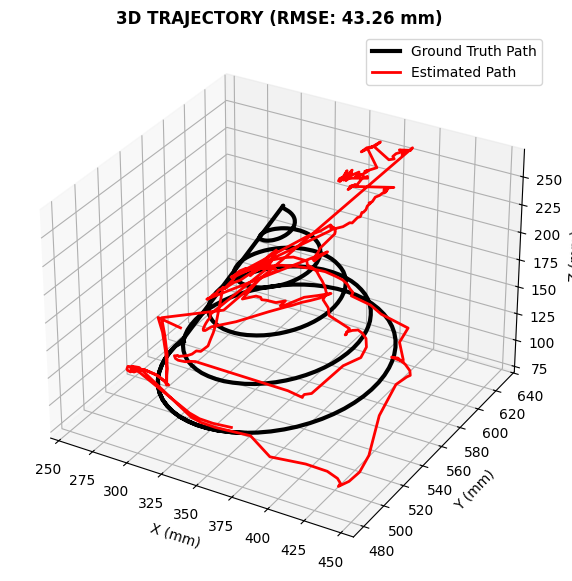

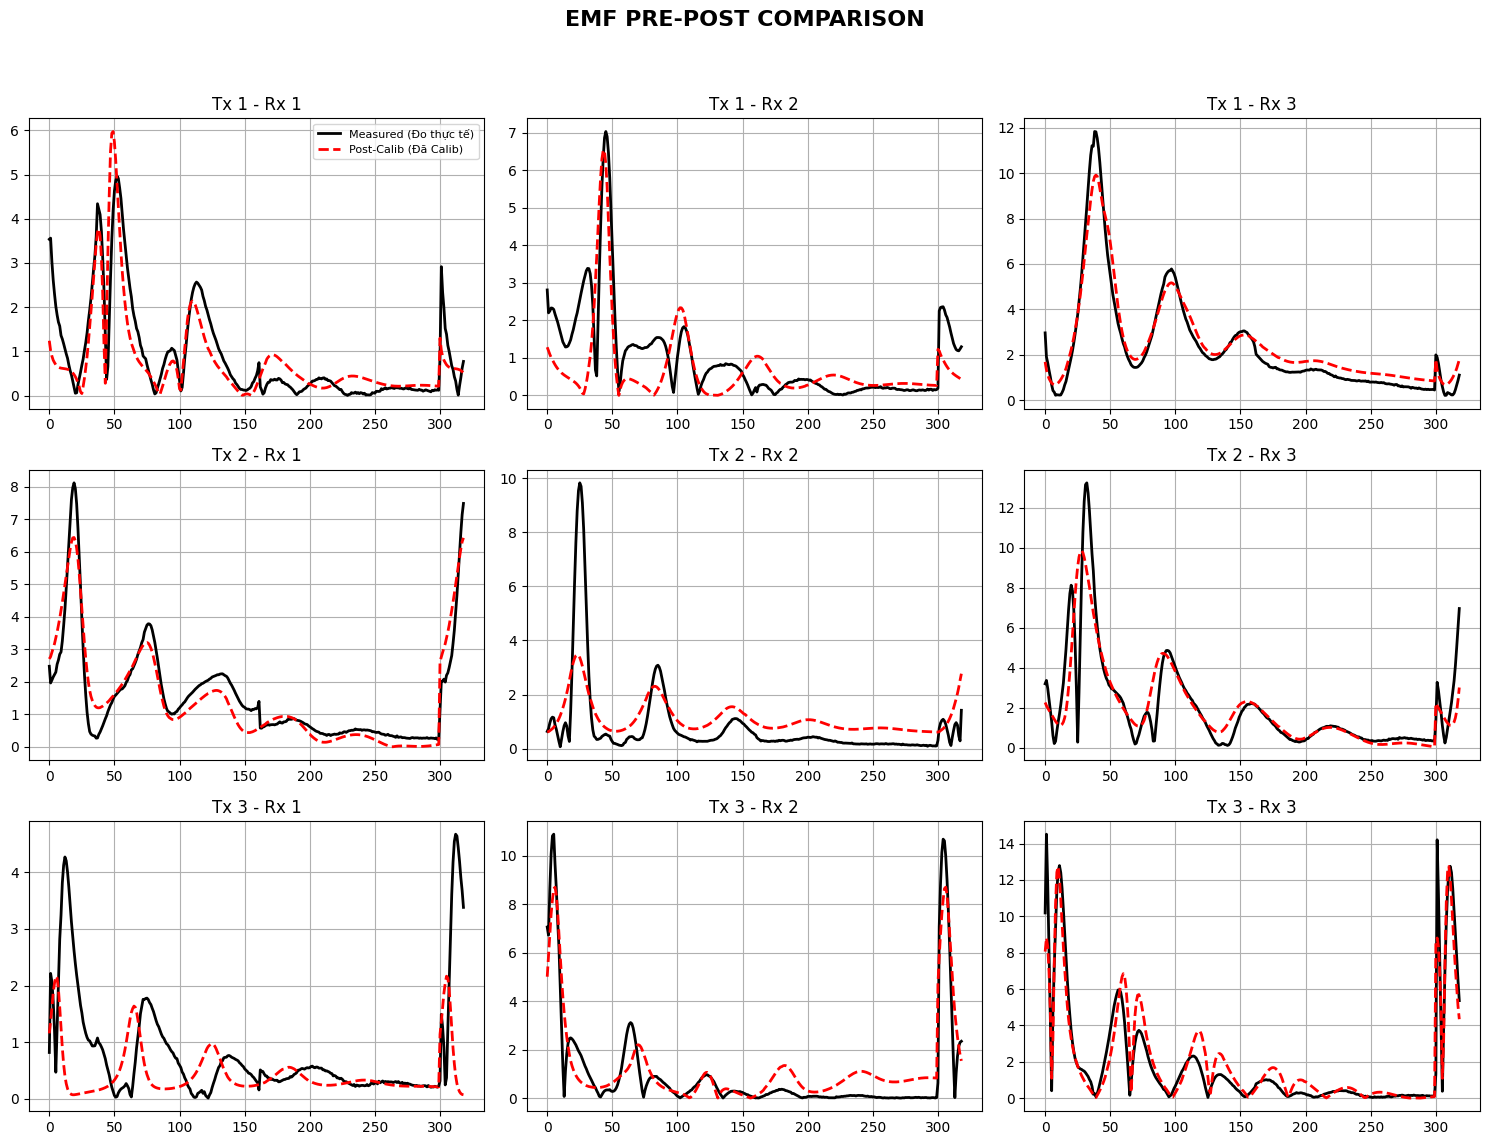

In [ ]:
# ==============================================================================
# SECTION 5: ĐÁNH GIÁ ĐỘ CHÍNH XÁC (RMSE) & VẼ ĐỒ THỊ TRỰC QUAN
# ==============================================================================

# 1. TÍNH TOÁN SAI SỐ RMSE (Root Mean Square Error)
# Lấy độ lệch chuẩn Euclidean giữa tọa độ giải mã (est_pose_post) và tọa độ thực tế (gt_pose)
err_post = np.linalg.norm(est_pose_post[:, 0:3] - gt_pose[:, 0:3], axis=1) * 1000 # Đổi ra mm
rmse_post = np.sqrt(np.mean(err_post**2))
print(f"🎯 RMSE Vị trí Post-Calib: {rmse_post:.2f} mm")

# 2. VẼ QUỸ ĐẠO 3D (3D Trajectory Plot)
fig1 = plt.figure(figsize=(10, 7))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(gt_pose[:,0]*1000, gt_pose[:,1]*1000, gt_pose[:,2]*1000, 'k-', linewidth=3, label='Ground Truth Path')
ax1.plot(est_pose_post[:,0]*1000, est_pose_post[:,1]*1000, est_pose_post[:,2]*1000, 'r-', linewidth=2, label='Estimated Path')
ax1.set_xlabel('X (mm)'); ax1.set_ylabel('Y (mm)'); ax1.set_zlabel('Z (mm)')
ax1.set_title(f'3D TRAJECTORY (RMSE: {rmse_post:.2f} mm)', fontweight='bold')
ax1.legend()
plt.show()

# 3. TÁI TẠO TÍN HIỆU EMF LÝ THUYẾT (Bài toán thuận)
emf_post_reconstruct = np.zeros((N_samples, 9))
for i in range(N_samples):
    for rx_idx in range(3):
        # Tính toán lại cường độ tín hiệu dựa trên bộ thông số tối ưu nhất
        emf_raw = forwardModel_dio(gt_pose[i, :], sys_post, rx_idx)
        emf_calibrated = K_post[rx_idx, :] * emf_raw
        emf_post_reconstruct[i, rx_idx*3 : rx_idx*3+3] = emf_calibrated

# 4. VẼ LƯỚI ĐỒ THỊ 3x3 SO SÁNH TÍN HIỆU EMF (Pre-Post Comparison)
fig2, axs = plt.subplots(3, 3, figsize=(15, 12))
fig2.suptitle('EMF PRE-POST COMPARISON', fontsize=16, fontweight='bold')

for rx in range(3):
    for tx in range(3):
        idx = tx + 3 * rx  # Công thức ánh xạ index chuẩn: Cột TX, Hàng RX
        ax = axs[tx, rx]   # Tráo trục (tx, rx) để vẽ TX theo hàng ngang

        # Đường màu đen: Tín hiệu đo từ phần cứng
        ax.plot(emf_meas[:, idx], 'k', linewidth=2, label='Measured (Đo thực tế)')

        # Đường màu đỏ nét đứt: Tín hiệu lý thuyết sau khi chạy Auto-Calibration
        ax.plot(emf_post_reconstruct[:, idx], 'r--', linewidth=2, label='Post-Calib (Đã Calib)')

        ax.set_title(f'Tx {tx+1} - Rx {rx+1}')
        ax.grid(True)
        if tx == 0 and rx == 0:
            ax.legend(loc='best', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()